In [1]:
import pandas as pd
import numpy as np

df=pd.read_pickle(f"./df.pkl")

In [2]:
df_pdm = df[df["dm"] == 1]

# 무작위 40명 추출 (항상 같은 결과)
df_test = df_pdm.sample(
    n=40,
    random_state=42
).reset_index(drop=True)

print(df_test.shape)

(40, 29)


In [3]:
df_test

,dm,sex,age,edu,income,job,glu,hba1c,chol,hdl,...,wk_mvpa_play,wk_walk,wk_sleep,stress,wk_break,wk_lunch,wk_dinner,wk_veg1,wk_veg2,wk_fruit
0,1,1.0,54.0,4.0,5.0,1.0,97.0,5.8,152.0,37.0,...,0.0,40.0,480.0,2.0,6.0,6.0,6.0,21.0,21.0,0.250
1,1,2.0,58.0,3.0,4.0,7.0,97.0,6.0,271.0,68.0,...,150.0,360.0,390.0,2.0,6.0,6.0,6.0,21.0,21.0,7.000
2,1,1.0,71.0,2.0,2.0,5.0,116.0,6.2,279.0,42.0,...,0.0,90.0,420.0,2.0,3.5,6.0,6.0,14.0,14.0,3.000
3,1,1.0,67.0,1.0,2.0,7.0,95.0,5.8,239.0,73.0,...,420.0,420.0,600.0,2.0,6.0,6.0,6.0,21.0,21.0,3.000
4,1,1.0,80.0,1.0,2.0,6.0,105.0,5.4,203.0,56.0,...,0.0,630.0,360.0,2.0,6.0,6.0,6.0,21.0,21.0,7.000
5,1,1.0,74.0,1.0,2.0,7.0,125.0,6.1,189.0,55.0,...,0.0,90.0,300.0,2.0,6.0,1.5,6.0,14.0,14.0,7.000
6,1,1.0,74.0,2.0,2.0,4.0,103.0,5.4,125.0,42.0,...,0.0,420.0,420.0,2.0,6.0,6.0,6.0,21.0,21.0,21.000
7,1,2.0,40.0,4.0,5.0,6.0,100.0,5.2,190.0,73.0,...,180.0,600.0,420.0,2.0,6.0,6.0,6.0,21.0,14.0,14.000
8,1,2.0,43.0,4.0,4.0,1.0,104.0,5.2,203.0,66.0,...,0.0,90.0,410.0,1.0,3.5,6.0,6.0,14.0,14.0,3.000
9,1,1.0,48.0,3.0,5.0,1.0,119.0,5.8,218.0,54.0,...,120.0,320.0,450.0,1.0,6.0,6.0,6.0,21.0,21.0,1.000


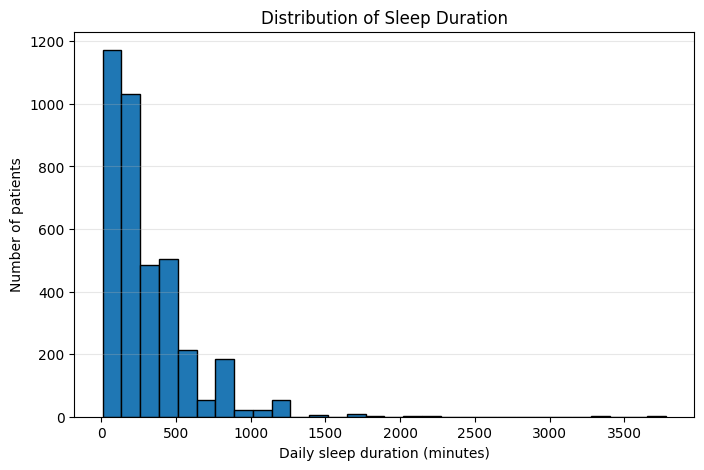

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_pdm["wk_walk"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Daily sleep duration (minutes)")
plt.ylabel("Number of patients")
plt.title("Distribution of Sleep Duration")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [5]:
from docx import Document
from docx.shared import Pt
from PFPD import PFPD

def get_references_from_context(ctx_item):
    refs = []
    for g in ctx_item.get("guidelines", []):
        meta = g.get("metadata", {})
        ref = meta.get("reference", "")
        if ref and ref not in refs:
            refs.append(ref)
    return "; ".join(refs)


def add_patient_recommendation_to_doc(doc, patient_no, X, current_score, deltas, final_score, recommendation_result, retrieved_context):
    doc.add_heading(f"Patient {patient_no}", level=1)

    doc.add_paragraph(f"Current progression score: {current_score:.3f}")
    doc.add_paragraph(f"Final progression score after lifestyle optimization: {final_score:.3f}")

    doc.add_heading("Recommended lifestyle modifications", level=2)

    for i, (item,ctx) in enumerate(zip(recommendation_result["action_items"],retrieved_context)):
        meta=ctx["item"]
        
        variable=meta["variable"]
        description=meta["description"]
        current_value=meta["current_value"]
        
        reference = get_references_from_context(ctx)
        
        doc.add_paragraph(f"{i+1}. {variable}", style=None)
        doc.add_paragraph(f"Variable: {description}")
        doc.add_paragraph(f"Current value: {current_value}")
        doc.add_paragraph(f"Recommendation: {item.get('recommendation based on delta')}")
        doc.add_paragraph(f"Rationale: {item.get('rationale')}")
        doc.add_paragraph(f"Reference: {reference}")

    doc.add_paragraph(
        "Disclaimer: These recommendations are generated to support lifestyle modification "
        "and do not replace professional medical advice. Please consult your healthcare provider "
        "before making major lifestyle changes."
    )


def generate_word_report_for_40_patients(df_test, output_path="recommendation_report_40_patients.docx"):
    pro = PFPD()
    doc = Document()

    doc.add_heading("Personalized Lifestyle Recommendation Report", level=0)

    for idx, row in df_test.iterrows():
        patient_no = idx + 1

        # row를 기존 X 형태의 dict로 변환
        X = row.to_dict()

        # 필요 없는 컬럼 제거: dm, id 등 모델에 안 들어가는 변수 제거
        for col in ["dm", "dm_binary", "id", "ID", "patient_id"]:
            X.pop(col, None)

        current_score = pro.dbs_progression(X)

        deltas, final_score = pro.lifestyle_rec(X)

        recommendation_result, retrieved_context = pro.make_patient_friendly_recommendation(X, deltas)

        add_patient_recommendation_to_doc(
            doc=doc,
            patient_no=patient_no,
            X=X,
            current_score=current_score,
            deltas=deltas,
            final_score=final_score,
            recommendation_result=recommendation_result,
            retrieved_context=retrieved_context
        )

        # 한 페이지당 2명
        if patient_no % 2 == 0 and patient_no != len(df_test):
            doc.add_page_break()
        else:
            doc.add_paragraph("\n" + "-" * 80 + "\n")

    doc.save(output_path)
    print(f"Saved: {output_path}")

In [6]:
generate_word_report_for_40_patients(
    df_test,
    output_path="recommendation_report_40_patients.docx"
)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\p

Personalized Lifestyle Recommendation

[1] stress
------------------------------------------------------------
Variable           : Self-reported stress level, from 1 to 4
Current value      : 2.0
Recommendation     : Work on reducing your stress level from 2 to about 1.3 by incorporating calming activities such as quick walks, relaxation exercises like meditation or yoga, spending quality time with supportive friends, taking personal breaks, going outside, reading fun materials, and ensuring proper self-care including limiting alcohol and caffeine, eating healthy, and getting enough sleep.
Rationale             : Controlling diabetes stress, anxiety, and depression is important as they can significantly increase A1C levels and decrease quality of life. Getting active and practicing relaxation techniques can help manage stress effectively according to the ADA Standards of Care (2026) and CDC guidelines.
Reference          : Diabetes and Mental Health (2024), Centers for Disease Control

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] stress
------------------------------------------------------------
Variable           : Self-reported stress level, from 1 to 4
Current value      : 2.0
Recommendation     : Try to reduce your stress level from 2 to about 1.2 by engaging in activities like quick walks, relaxation exercises such as meditation or yoga, connecting with supportive friends, and taking regular breaks to recharge. Also, focus on self-care by limiting alcohol and caffeine intake, eating healthy food, and ensuring sufficient sleep.
Rationale             : Controlling stress, anxiety, and depression in prediabetes patients is important as they can significantly increase A1C levels and reduce quality of life according to the Psychological Care guidelines. Additionally, engaging in calming activities and self-care practices helps manage stress effectively as described in the Diabetes and Mental Health guidelines.
Reference          : Diabetes and Mental Health (2024), Ce

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

...

Personalized Lifestyle Recommendation

[1] stress
------------------------------------------------------------
Variable           : Self-reported stress level, from 1 to 4
Current value      : 2.0
Recommendation     : Try to reduce your stress level from 2.0 closer to about 1.5 by incorporating calming activities such as quick walks, relaxation exercises like meditation or yoga, reaching out to supportive friends, and taking personal breaks to recharge.
Rationale             : Controlling stress, anxiety, and depression is important in prediabetes as they can significantly increase A1C levels and decrease quality of life. Activities like walking and relaxation help manage stress effectively. Additionally, limiting alcohol and caffeine, eating healthy foods, and ensuring enough sleep are beneficial for stress management as stated in the ADA guidelines.
Reference          : Diabetes and Mental Health (2024), Centers for Disease Control and Prevention; Psychological Care, section 5, ADA S

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] wk_fruit
------------------------------------------------------------
Variable           : Weekly frequency of fruit consumption
Current value      : 7.0
Recommendation     : Increase your weekly fruit consumption by about 4 to 5 times, aiming for approximately 11 to 12 times per week.
Rationale             : Especially whole fruit—fresh, frozen, or canned in own juice (or no added sugar) are all acceptable fruit options according to Medical Nutrition Therapy, section 5, ADA Standards of Care (2026).
Reference          : Medical Nutrition Therapy, section 5, ADA Standards of Care (2026)

[2] stress
------------------------------------------------------------
Variable           : Self-reported stress level, from 1 to 4
Current value      : 2.0
Recommendation     : Try to reduce your stress level from 2 to about 1 to 1.5 by engaging in activities such as walking, meditation, or yoga, taking breaks, connecting with supportive friends, and caring 

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] wk_fruit
------------------------------------------------------------
Variable           : Weekly frequency of fruit consumption
Current value      : 7.0
Recommendation     : Increase your fruit consumption to about 9 to 10 times per week, focusing especially on whole fruits including fresh, frozen, or canned in their own juice without added sugar.
Rationale             : Especially whole fruit—fresh, frozen, or canned in own juice (or no added sugar) are all acceptable fruit options according to Medical Nutrition Therapy, section 5, ADA Standards of Care (2026).
Reference          : Medical Nutrition Therapy, section 5, ADA Standards of Care (2026)

[2] wk_mvpa_play
------------------------------------------------------------
Variable           : Weekly minutes of moderate-to-vigorous physical activity
Current value      : 0.0
Recommendation     : Begin engaging in moderate-to-vigorous physical activity for approximately 45 to 50 minutes per 

In [7]:
# Patient 10만 다시 생성/출력

from PFPD import PFPD
from llm_writer import print_recommendation

pro = PFPD()

# df_test에서 10번째 환자
row = df_test.iloc[9]
X = row.to_dict()

# 모델에 안 들어가는 컬럼 제거
for col in ["dm", "dm_binary", "id", "ID", "patient_id"]:
    X.pop(col, None)

current_score = pro.dbs_progression(X)
deltas, final_score = pro.lifestyle_rec(X)

# recommendation 생성
recommendation_result, retrieved_context = pro.make_patient_friendly_recommendation(X, deltas)

# mismatch 확인
vars_from_context = [ctx["item"]["variable"] for ctx in retrieved_context]
vars_from_llm = [item["variable"] for item in recommendation_result["action_items"]]

print("context:", vars_from_context)
print("llm    :", vars_from_llm)

assert vars_from_context == vars_from_llm, "Variable mismatch occurred"

print("Current score:", current_score)
print("Final score:", final_score)

print_recommendation(recommendation_result, retrieved_context)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\p

Personalized Lifestyle Recommendation

[1] wk_smk
------------------------------------------------------------
Variable           : Weekly frequency of smoking
Current value      : 77.0
Recommendation     : Try to reduce your smoking frequency from 77 times per week to lower levels, aiming towards quitting completely for optimal health benefits.
Rationale             : Smoking cessation is recommended because it reduces the risk of cardiovascular disease and all-cause mortality. Moreover, the longer you remain smoke-free, the lower your risk of developing type 2 diabetes, according to ADA guidelines on Smoking cessation.
Reference          : Smoking cessation, section 5, ADA Standards of Care (2026)

[2] wk_mvpa_play
------------------------------------------------------------
Variable           : Weekly minutes of moderate-to-vigorous physical activity
Current value      : 120.0
Recommendation     : Increase your weekly moderate-to-vigorous physical activity from 120 minutes to about 

In [7]:
print(f"current score: {pro.dbs_progression(X)}")
deltas, final_score = pro.lifestyle_rec(X)

print(f"recommend: {deltas}")
print(f"final score: {final_score}")

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

current score: 65.5223388671875


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-p

recommend: {'wk_mvpa_play': np.float64(116.27), 'wk_sleep': np.float64(-62.41), 'wk_lunch': np.float64(-2.58), 'wk_fruit': np.float64(-1.0), 'wk_smk': np.float64(-57.83), 'wk_break': np.float64(-2.0), 'wk_dinner': np.float64(-1.47), 'wk_alc': np.float64(0.0)}
final score: 65.02140808105469


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

In [8]:
X

{'sex': 1.0,
 'age': 48.0,
 'edu': 3.0,
 'income': 5.0,
 'job': 1.0,
 'glu': 119.0,
 'hba1c': 5.8,
 'chol': 218.0,
 'hdl': 54.0,
 'tg': 220.0,
 'ldl': 143.0,
 'sbp': 134.0,
 'wt': 83.5,
 'ht': 178.0,
 'wc': 97.4,
 'bmi': 26.353995707612675,
 'wk_smk': 77.0,
 'wk_alc': 25.0,
 'wk_mvpa_play': 120.0,
 'wk_walk': 320.0,
 'wk_sleep': 450.0,
 'stress': 1.0,
 'wk_break': 6.0,
 'wk_lunch': 6.0,
 'wk_dinner': 6.0,
 'wk_veg1': 21.0,
 'wk_veg2': 21.0,
 'wk_fruit': 1.0}